In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the CSV file
ecdc = pd.read_csv("dengue2019.csv")
ecdc.head()

,HealthTopicCode,MeasureCode,TimeUnit,TimeCode,GeoCode,XValue,XLabel,YValue,YLabel,ZValue,N
0,DENGUE,ALL.AGE.PROPORTION,M,2016-01,HR,1.0,0-4,NaN,NaN,NaN,0
1,DENGUE,ALL.AGE.PROPORTION,M,2016-01,HR,2.0,5-14,NaN,NaN,NaN,0
2,DENGUE,ALL.AGE.PROPORTION,M,2016-01,HR,3.0,15-24,NaN,NaN,NaN,0
3,DENGUE,ALL.AGE.PROPORTION,M,2016-01,HR,4.0,25-44,NaN,NaN,NaN,0
4,DENGUE,ALL.AGE.PROPORTION,M,2016-01,HR,5.0,45-64,NaN,NaN,NaN,0


In [3]:
# Group by country and count cases
cases_by_country = ecdc.groupby("GeoCode")["N"].sum().reset_index()

# Sort by number of cases descending
cases_by_country = cases_by_country.sort_values("N", ascending=False)

print(cases_by_country)
# --> Germany has the highest number of dengue cases in 2019

     GeoCode        N
8   EU_EEA31  1173689
7       EU28  1143269
3         DE   361152
28        UK   229010
10        FR   189404
6         ES    86622
25        SE    73128
15        IT    56584
0         AT    46728
1         BE    40936
21        NO    30624
9         FI    24816
22        PL    14538
12        HU     9712
23        PT     7186
13        IE     6248
18        LV     4312
26        SI     3784
4         EE     3608
24        RO     3604
16        LT     2950
20        NL     2070
27        SK     1846
5         EL     1492
19        MT      704
11        HR      622
14        IS      528
17        LU      223
2         CZ        0


## Germany

In [4]:
# Filter for Germany
germany = ecdc[ecdc["GeoCode"] == "DE"]
germany

,HealthTopicCode,MeasureCode,TimeUnit,TimeCode,GeoCode,XValue,XLabel,YValue,YLabel,ZValue,N
17554,DENGUE,DATASOURCE.GEO.TYPE,Y,2015,DE,1.0,Yes,NaN,NaN,NaN,722
17555,DENGUE,DATASOURCE.GEO.TYPE,Y,2016,DE,1.0,Yes,NaN,NaN,NaN,958
17556,DENGUE,DATASOURCE.GEO.TYPE,Y,2017,DE,1.0,Yes,NaN,NaN,NaN,635
17557,DENGUE,DATASOURCE.GEO.TYPE,Y,2018,DE,1.0,Yes,NaN,NaN,NaN,614
17558,DENGUE,DATASOURCE.GEO.TYPE,Y,2019,DE,1.0,Yes,NaN,NaN,NaN,1175
...,...,...,...,...,...,...,...,...,...,...,...
44203,DENGUE,ALL.MALETOFEMALE.RATIO,Y,2015,DE,1.0,NaN,1.136499,NaN,NaN,722
44204,DENGUE,ALL.MALETOFEMALE.RATIO,Y,2016,DE,1.0,NaN,0.931452,NaN,NaN,958
44205,DENGUE,ALL.MALETOFEMALE.RATIO,Y,2017,DE,1.0,NaN,1.088816,NaN,NaN,635
44206,DENGUE,ALL.MALETOFEMALE.RATIO,Y,2018,DE,1.0,NaN,1.077966,NaN,NaN,614


In [5]:
ecdc[ecdc["GeoCode"] == "DE"]["MeasureCode"].unique()

array(['DATASOURCE.GEO.TYPE', 'DATASOURCE.SAMPLE.TYPE',
       'ALL.AGE_GENDER.RATE', 'ALL.AGE_GENDER.PROPORTION',
       'ALL.AGE_GENDER.COUNT', 'ALL.AGE.RATE', 'ALL.AGE.PROPORTION',
       'ALL.AGE.COUNT', 'DATASOURCE.COVERAGE.PROPORTION',
       'CONFIRMED.COUNT', 'ALL.RATE', 'ALL.AGESTANDARDISED.RATE',
       'ALL.COUNT', 'ALL.GENDER.COUNT', 'ALL.GENDER.PROPORTION',
       'ALL.GENDER.RATE', 'ALL.MALETOFEMALE.RATIO'], dtype=object)

In [6]:
ecdc[(ecdc["GeoCode"] == "DE") & (ecdc["MeasureCode"] == "ALL.COUNT")]['TimeCode']

34735    2015-01
34736    2015-02
34737    2015-03
34738    2015-04
34739    2015-05
          ...   
34795       2015
34796       2016
34797       2017
34798       2018
34799       2019
Name: TimeCode, Length: 65, dtype: object

In [7]:
# Filter for dengue cases in Germany
germany = ecdc[(ecdc["GeoCode"] == "DE") & (ecdc["MeasureCode"] == "ALL.COUNT")]
germany.head(10)

,HealthTopicCode,MeasureCode,TimeUnit,TimeCode,GeoCode,XValue,XLabel,YValue,YLabel,ZValue,N
34735,DENGUE,ALL.COUNT,M,2015-01,DE,1.0,NaN,59.0,NaN,NaN,59
34736,DENGUE,ALL.COUNT,M,2015-02,DE,1.0,NaN,36.0,NaN,NaN,36
34737,DENGUE,ALL.COUNT,M,2015-03,DE,1.0,NaN,69.0,NaN,NaN,69
34738,DENGUE,ALL.COUNT,M,2015-04,DE,1.0,NaN,92.0,NaN,NaN,92
34739,DENGUE,ALL.COUNT,M,2015-05,DE,1.0,NaN,56.0,NaN,NaN,56
34740,DENGUE,ALL.COUNT,M,2015-06,DE,1.0,NaN,51.0,NaN,NaN,51
34741,DENGUE,ALL.COUNT,M,2015-07,DE,1.0,NaN,36.0,NaN,NaN,36
34742,DENGUE,ALL.COUNT,M,2015-08,DE,1.0,NaN,61.0,NaN,NaN,61
34743,DENGUE,ALL.COUNT,M,2015-09,DE,1.0,NaN,56.0,NaN,NaN,56
34744,DENGUE,ALL.COUNT,M,2015-10,DE,1.0,NaN,65.0,NaN,NaN,65


In [10]:
# Convert TimeCode to datetime and filter only monthly data (exclude yearly data)
germany['TimeCode'] = pd.to_datetime(germany['TimeCode'], format='%Y-%m', errors='coerce')

# Remove rows where TimeCode could not be converted (likely yearly data, e.g., '2019')
germany = germany.dropna(subset=['TimeCode'])

germany = germany.sort_values("TimeCode")[['TimeCode', 'N']]
print(len(germany))
germany.head()

60


,TimeCode,N
34735,2015-01-01,59
34736,2015-02-01,36
34737,2015-03-01,69
34738,2015-04-01,92
34739,2015-05-01,56


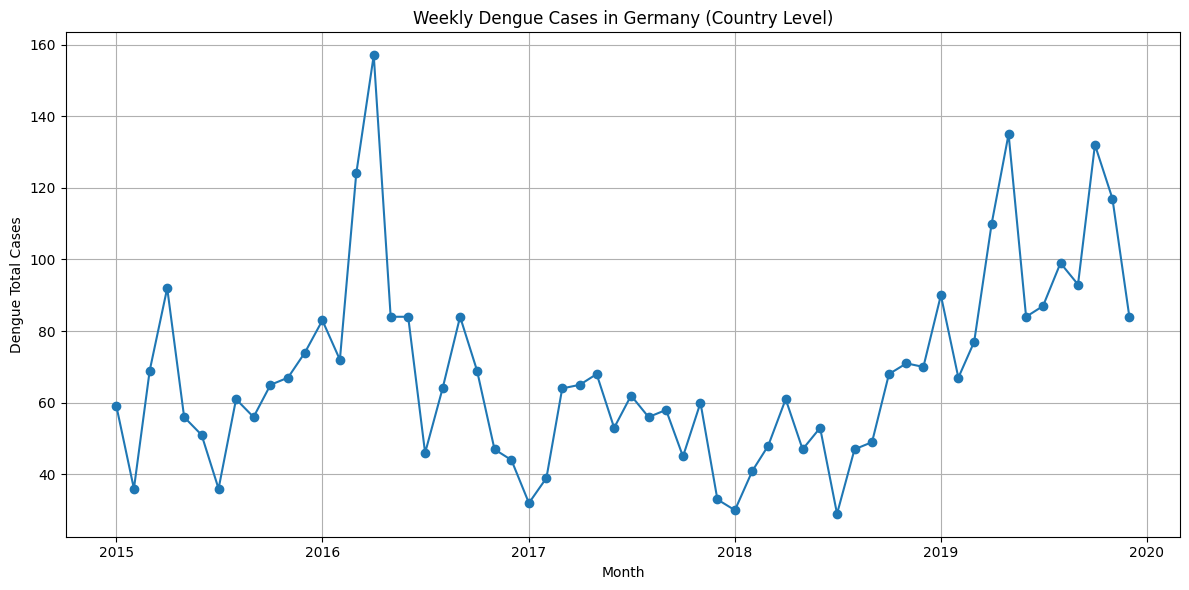

In [11]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(germany["TimeCode"], germany["N"], marker='o')
plt.title("Weekly Dengue Cases in Germany (Country Level)")
plt.xlabel("Month")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

## EU

In [4]:
# Filter for dengue cases in Germany
germany = ecdc[(ecdc["GeoCode"] == "EU_EEA31") & (ecdc["MeasureCode"] == "ALL.COUNT")]
germany.head(10)

,HealthTopicCode,MeasureCode,TimeUnit,TimeCode,GeoCode,XValue,XLabel,YValue,YLabel,ZValue,N
34995,DENGUE,ALL.COUNT,M,2015-01,EU_EEA31,1.0,NaN,177.0,NaN,NaN,177
34996,DENGUE,ALL.COUNT,M,2015-02,EU_EEA31,1.0,NaN,124.0,NaN,NaN,124
34997,DENGUE,ALL.COUNT,M,2015-03,EU_EEA31,1.0,NaN,178.0,NaN,NaN,178
34998,DENGUE,ALL.COUNT,M,2015-04,EU_EEA31,1.0,NaN,224.0,NaN,NaN,224
34999,DENGUE,ALL.COUNT,M,2015-05,EU_EEA31,1.0,NaN,157.0,NaN,NaN,157
35000,DENGUE,ALL.COUNT,M,2015-06,EU_EEA31,1.0,NaN,130.0,NaN,NaN,130
35001,DENGUE,ALL.COUNT,M,2015-07,EU_EEA31,1.0,NaN,174.0,NaN,NaN,174
35002,DENGUE,ALL.COUNT,M,2015-08,EU_EEA31,1.0,NaN,282.0,NaN,NaN,282
35003,DENGUE,ALL.COUNT,M,2015-09,EU_EEA31,1.0,NaN,223.0,NaN,NaN,223
35004,DENGUE,ALL.COUNT,M,2015-10,EU_EEA31,1.0,NaN,171.0,NaN,NaN,171


In [5]:
# Convert TimeCode to datetime and filter only monthly data (exclude yearly data)
germany['TimeCode'] = pd.to_datetime(germany['TimeCode'], format='%Y-%m', errors='coerce')

# Remove rows where TimeCode could not be converted (likely yearly data, e.g., '2019')
germany = germany.dropna(subset=['TimeCode'])

germany = germany.sort_values("TimeCode")[['TimeCode', 'N']]
print(len(germany))
germany.head()

60


,TimeCode,N
34995,2015-01-01,177
34996,2015-02-01,124
34997,2015-03-01,178
34998,2015-04-01,224
34999,2015-05-01,157


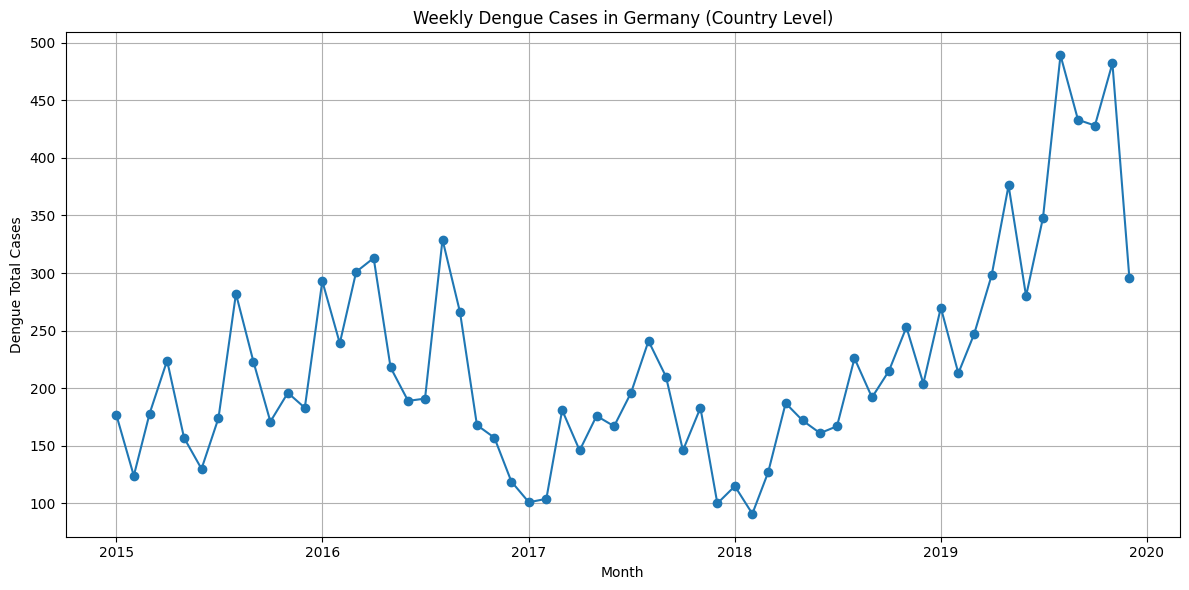

In [6]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(germany["TimeCode"], germany["N"], marker='o')
plt.title("Weekly Dengue Cases in Germany (Country Level)")
plt.xlabel("Month")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()